<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>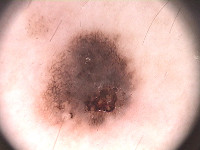</td><td>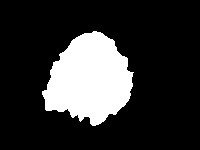</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [16]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=49247561-a803-4f0f-8b55-8bf97cc03f50
To: /kaggle/working/PH2Dataset.rar
100%|█████████████████████████████████████████| 162M/162M [00:01<00:00, 161MB/s]


In [17]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [139]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [140]:
type(images[0]), images[0].shape

(numpy.ndarray, (574, 764, 3))

In [141]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [142]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

In [143]:
np.unique(Y[3])

array([0., 1.], dtype=float32)

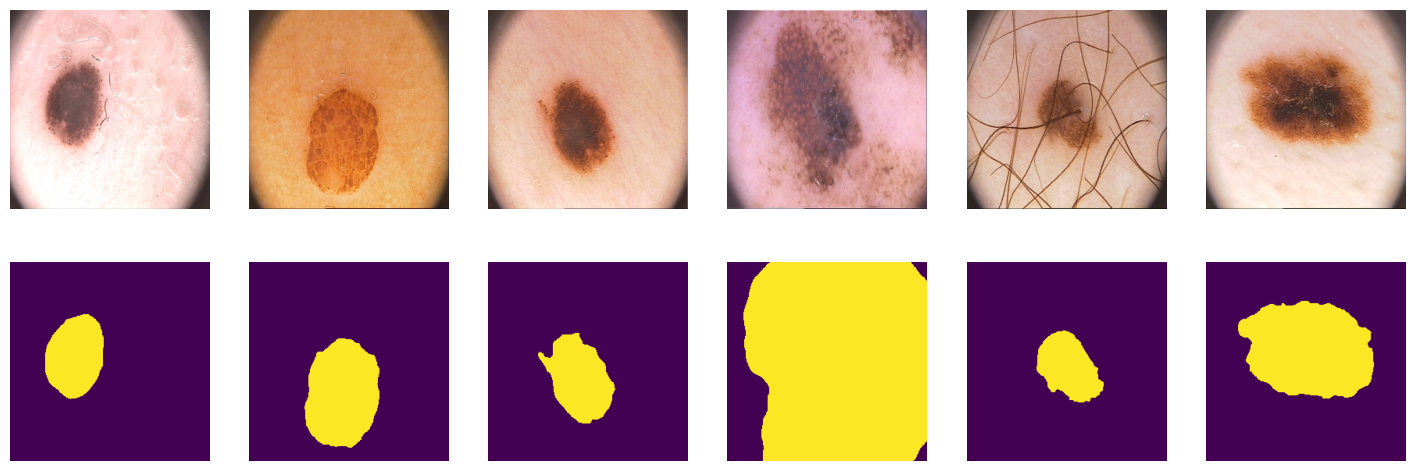

In [144]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show()

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [145]:
type(X[i])

numpy.ndarray

In [146]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [147]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [148]:
import torch
import torchvision.transforms as T
import numpy as np

In [149]:
np.mean(np.random.randn(2, 3, 4), axis=(1, 2))

array([-0.0504617 , -0.68131855])

In [150]:
np.arange(10)**2
X[0].shape

(256, 256, 3)

In [151]:
mean = np.zeros(3)
std = np.zeros(3)
for i in tr:
    mean += np.sum(X[i], axis=(0, 1))
    std += np.sum(X[i]**2, axis=(0, 1))
mean /= len(tr) * np.prod(X[0].shape[:2])
std /= len(tr) * np.prod(X[0].shape[:2])
std - mean**2
print(f'mean: {mean}')
print(f'std: {std}')

mean: [0.75449451 0.57214141 0.48178001]
std: [0.6065858  0.36452448 0.27137796]


In [152]:
trans = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(),
    T.RandomResizedCrop(256, scale=(0.4, 0.9)),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    T.ToTensor(),
    # T.Normalize(torch.tensor(mean), torch.tensor(std))
])
def collate_fn(batch):

    # for x_batch, y_batch in batch:
    #     trans(x_batch.transpose(1, 2, 0))
    #     break
    # assert False
    x_batch, y_batch = zip(*batch)
    x_batch = torch.stack([ trans(t.transpose(1, 2, 0)) for t in x_batch ])
    y_batch = torch.stack([ torch.tensor(t) for t in y_batch])
    return x_batch, y_batch


In [228]:
from torch.utils.data import DataLoader
batch_size = 15
# train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
#                      batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [205]:
len(next(iter(train_dataloader)))

2

In [206]:
for x_batch, y_batch in train_dataloader:
    print(x_batch.shape, y_batch.shape)

torch.Size([25, 3, 256, 256]) torch.Size([25, 1, 256, 256])
torch.Size([25, 3, 256, 256]) torch.Size([25, 1, 256, 256])
torch.Size([25, 3, 256, 256]) torch.Size([25, 1, 256, 256])
torch.Size([25, 3, 256, 256]) torch.Size([25, 1, 256, 256])


In [156]:
type(X[0]), X[0].shape

(numpy.ndarray, (256, 256, 3))

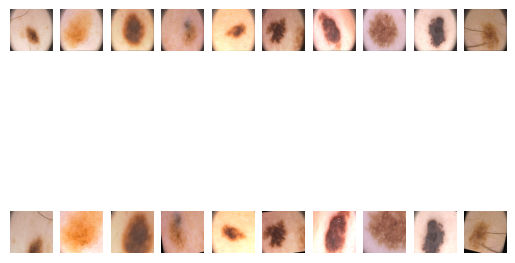

In [157]:
ind = np.random.choice(len(X), 10, replace=False)
for idx, i in enumerate(ind):
    plt.subplot(2, 10, idx+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 10, idx+11)
    plt.axis("off")
    plt.imshow(trans(X[i]).permute(1, 2, 0))

In [158]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 47.4 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in 
exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in 
wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", 
line 179, in resolve
    self.factory.preparer.prepare_linked_requirements_more(reqs)
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/operations/prepare.py", line 554, in 
prepare_linked_requirements_more
    self._complete_partial_requ

In [ ]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## BCE Loss [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [159]:
import torch.nn.functional as F
import torch.nn as nn

In [160]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [161]:
def bce_loss(y_pred, y_real):
    y_real = y_real.to(torch.float)
    return (y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))).sum()

def bce_true(y_pred, y_real):
    y_real = y_real.to(torch.float)
    return bce_torch_with_logits(y_pred, y_real)

Проверим корректность работы на простом примере

In [162]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 4.76398229598999
BCE loss честно посчитанный = 4.763982772827148
BCE loss from torch bce_torch = 4.763982772827148
BCE loss from torch with logits bce_torch = 4.763982772827148


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [163]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [164]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 11.840593338012695
BCE loss честно посчитанный = 11.840593338012695
BCE loss from torch bce_torch = 11.840593338012695
BCE loss from torch with logits bce_torch = 11.840593338012695


In [165]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [166]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 6.44MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 7.47MB/s]
Download completed


In [167]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

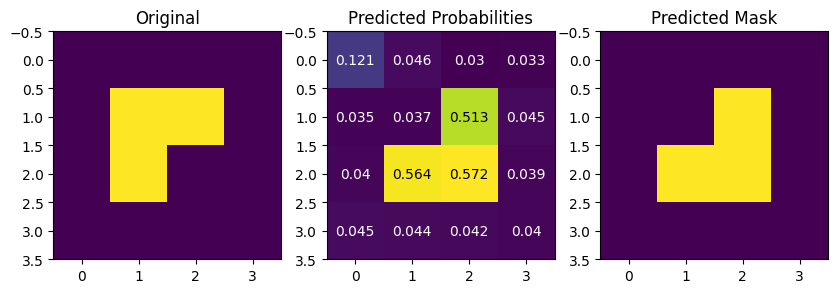

In [168]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [169]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

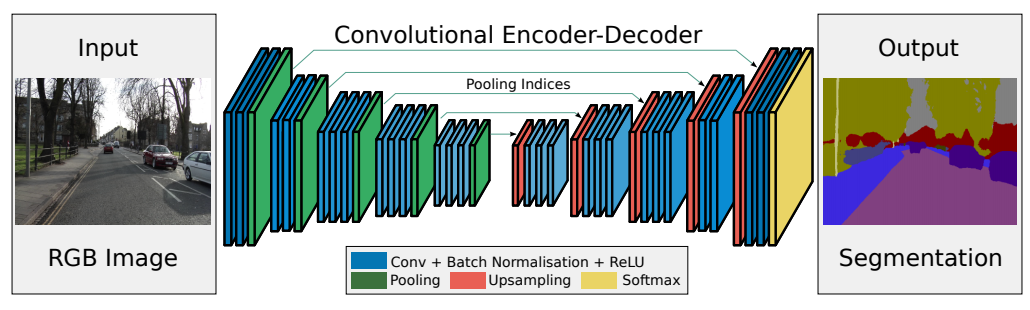

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

In [170]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


In [229]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()

        self.seq = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, X):
        return self.seq(X)

In [230]:
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, stride=1, padding=1):
        super().__init__()

        self.seq = nn.Sequential(
            *[ ConvBlock(in_channels if i == 0 else out_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding)
                for i in range(depth) ]
        )
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)

    def forward(self, x):
        x = self.seq(x)
        x = self.pool(x)
        return x

In [231]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size=3, stride=1, padding=1, classification=False):
        super().__init__()

        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)

        self.seq = nn.Sequential()
        for i in range(depth):
            if i == depth - 1:
                if classification:
                    self.seq.append(nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding))
                else:
                    self.seq.append(ConvBlock(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding))
            else:
                self.seq.append(ConvBlock(in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding))
    def forward(self, x, indices):
        x = self.unpool(x, indices)
        x = self.seq(x)
        return x

In [232]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # VGG-16 architecture
        self.enc0 = EncoderBlock(3, 64, 2)
        self.enc1 = EncoderBlock(64, 128, 2)
        self.enc2 = EncoderBlock(128, 256, 3)
        self.enc3 = EncoderBlock(256, 512, 3)

        self.bottleneck_enc = EncoderBlock(512, 512, 3)
        self.bottleneck_dec = DecoderBlock(512, 512, 3)

        self.dec3 = DecoderBlock(512, 256, 3)
        self.dec2 = DecoderBlock(256, 128, 3)
        self.dec1 = DecoderBlock(128, 64, 2)
        self.dec0 = DecoderBlock(64, 1, 2, classification=True)
        self.sigma = nn.Sigmoid()

    def forward(self, x):
        # encoder
        # TODO
        out, ind0 = self.enc0(x)
        out, ind1 = self.enc1(out)
        out, ind2 = self.enc2(out)
        out, ind3 = self.enc3(out)

        out, ind_bottle = self.bottleneck_enc(out)
        out = self.bottleneck_dec(out, ind_bottle)

        out = self.dec3(out, ind3)
        out = self.dec2(out, ind2)
        out = self.dec1(out, ind1)
        out = self.dec0(out, ind0)
        out = self.sigma(out)

        return out


In [233]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [234]:
from tqdm.notebook import tqdm
import time

In [235]:
out_ = []
def train_epoch(model, train_loader, opt, criteion):

    train_loss = 0
    train_acc = 0
    num = 0


    model.train()
    for x_batch, y_batch in tqdm(train_loader):
        # return y_batch, y_batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        out = model(x_batch)
        # out_ += [out.min().item(), out.max().item()]
        loss = criteion(out, y_batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        pred = torch.where(out > 0.5, 1, 0)
        train_acc += torch.sum(pred == y_batch).item()
        train_loss += loss.item()
        num += len(x_batch)

    train_loss /= num
    num *= np.prod(x_batch.shape[2:])
    train_acc /= num
    return train_loss, train_acc

def val_epoch(model, val_loader, criteion):
    val_loss = 0
    val_acc = 0
    num = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            out = model(x_batch)
            loss = criteion(out, y_batch)

            pred = torch.where(out > 0.5, 1, 0)
            val_acc += torch.sum(pred == y_batch).item()
            val_loss += loss.item()
            num += len(x_batch)

    val_loss /= num
    num *= np.prod(x_batch.shape[2:])
    val_acc /= num
    return val_loss, val_acc

In [236]:
def train(model, train_loader, val_loader, opt, criterion,  epochs=10, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    lrs = [opt.param_groups[0]['lr']]

    with tqdm(desc="epoch", total=epochs) as pbar_outer:

        fig, axs = plt.subplots(1, 3, figsize=(8, 8))
        # plt.ylim(10**4, 3 * 10**4)
        plt.grid(True)
        plt.figure(figsize=(12, 5))

        for epoch in range(epochs):
            print(f"Epoch: {epoch}/{epochs}")
            train_loss, train_acc = train_epoch(model, train_loader, opt, criterion)
            # return train_loss
            val_loss, val_acc = val_epoch(model, val_loader, criterion)
            if scheduler is not None:
                try:
                    scheduler.step()
                except:
                    scheduler.step(val_acc)
            lrs.append(opt.param_groups[0]['lr'])
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            general["train_loss"].append(train_loss)
            general["train_acc"].append(train_acc)
            general["val_loss"].append(val_loss)
            general["val_acc"].append(val_acc)

            clear_output()
            pbar_outer.update(1)
            print(lrs)
            print(f'train loss: {history["train_loss"][-1]}')
            print(f'validation loss: {history["val_loss"][-1]}')
            print(f'train accuracy: {history["train_acc"][-1]}')
            print(f'validation accuracy: {history["val_acc"][-1]}')

            # plt.yscale('linear')
            # plt.ylim(0.8, 1)
            plt.subplot(1, 3, 2)
            # plt.cla()
            plt.plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Accuracy', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Accuracy', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=12)

            plt.subplot(1, 3, 3)
            plt.plot(lrs, label='Learning Rate', linewidth=2, color='royalblue', marker='o')
            plt.title('Learning Rate through epochs', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Learning Rate', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=12)

            plt.subplot(1, 3, 1)
            # plt.cla()
            plt.plot(history['train_loss'], label='Train Loss', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Loss', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Loss', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=12)
            plt.ylim(10**3, 6 * 10**4)

            plt.tight_layout()
            plt.show()

    return history

In [237]:
general = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [241]:
model = SegNet().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-2)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'max', factor=0.5, patience=3)
# criterion = nn.BCELoss(reduction='sum')
criterion = bce_loss

In [242]:
val_dataloader = valid_dataloader

epoch:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 0/30


  0%|          | 0/7 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 240.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 54.12 MiB is free. Process 122691 has 14.69 GiB memory in use. Of the allocated memory 14.54 GiB is allocated by PyTorch, and 23.38 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

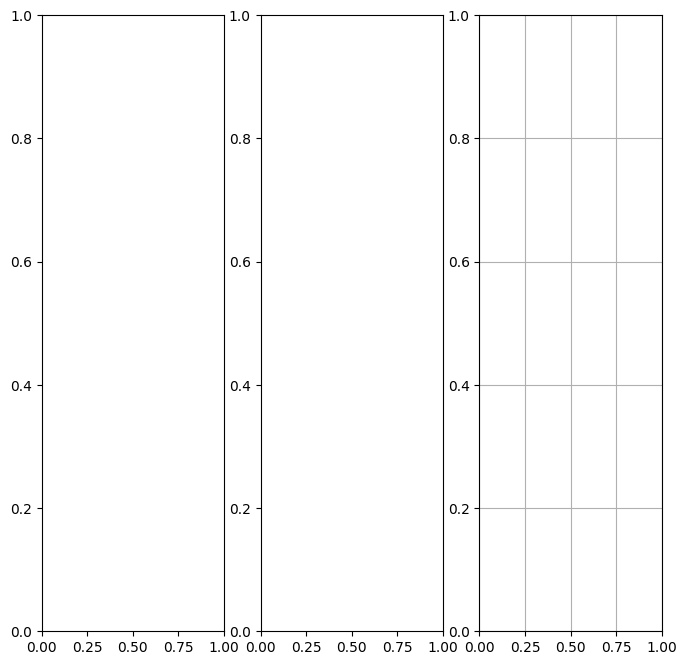

<Figure size 1200x500 with 0 Axes>

In [243]:
history = train(model, train_dataloader, val_dataloader, opt, criterion, epochs=30, scheduler=None)

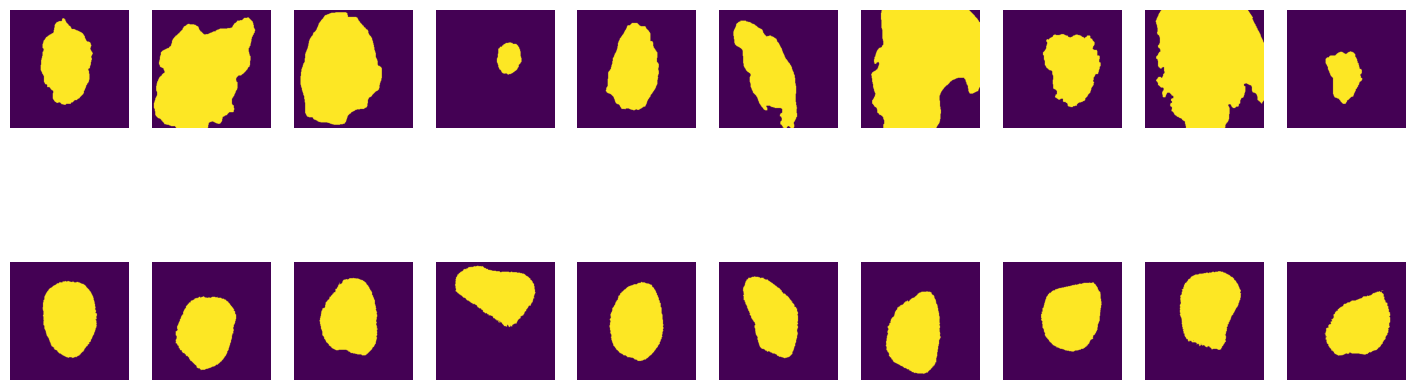

In [203]:
ind = np.random.choice(len(X), 10, replace=True)
plt.figure(figsize=(18, 6))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.axis("off")
    plt.imshow(Y[ind[i]])

    plt.subplot(2, 10, i+11)
    plt.axis("off")
    ans = T.ToTensor()(X[ind[i]]).unsqueeze(0).to(device)
    # print(ans.shape)
    ans = model(ans).squeeze()
    # print(ans.shape)
    ans = torch.where(ans > 0.5, 1, 0)
    plt.imshow(ans.cpu().detach().numpy())
plt.show()

## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [53]:
def test(model, test_loader):
    iou_numerator = 0
    iou_denominator = 0
    acc = 0
    num = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device=device, dtype=torch.long)

            out = model(x_batch)
            pred = torch.where(out > 0.5, 1, 0)
            acc += torch.sum(pred == y_batch).item()
            iou_numerator += (pred & y_batch).sum().item()
            iou_denominator += (pred | y_batch).sum().item()
            num += len(x_batch)

    num *= np.prod(x_batch.shape[2:])
    acc /= num
    return acc, iou_numerator / iou_denominator

In [54]:
acc, iou = test(model, test_dataloader)
print(f'test accuracy: {acc}')
print(f'test iou: {iou}')

test accuracy: 0.8618096923828125
test iou: 0.5924696954560958


# Мир других лоссов!

## Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [ ]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    # TODO

    return score

Проверим на корректность функцию dice_score:

In [ ]:
from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.6667)

In [ ]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    '''
    Это лосс.
    '''
    # TODO

    return loss

Проверка на корректность:

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    # TODO

    return loss

Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



# Новая модель!

In [5]:
for i in range(3, 20):
    print(f'{i} - {15 * (i - 1) / 16}')

3 - 1.875
4 - 2.8125
5 - 3.75
6 - 4.6875
7 - 5.625
8 - 6.5625
9 - 7.5
10 - 8.4375
11 - 9.375
12 - 10.3125
13 - 11.25
14 - 12.1875
15 - 13.125
16 - 14.0625
17 - 15.0
18 - 15.9375
19 - 16.875


## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

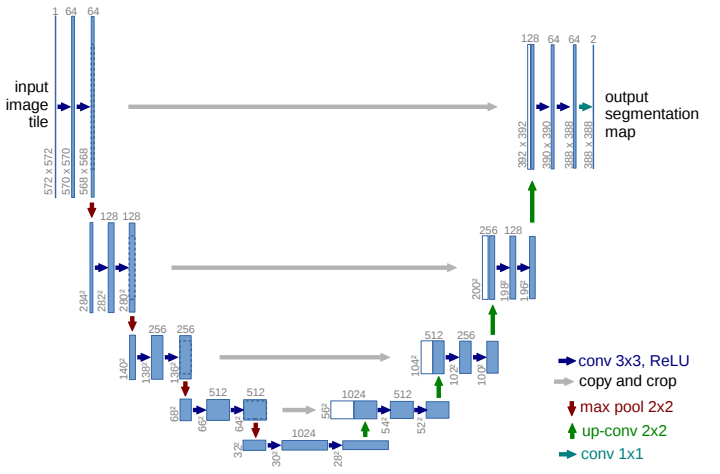

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

In [18]:
import torch.nn.functional as F
import torch.nn as nn

In [19]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

In [20]:
len(images)

200

In [114]:
type(images[0]), images[0].shape

(numpy.ndarray, (576, 766, 3))

In [115]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [116]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


In [117]:
np.unique(Y[3])

array([0., 1.], dtype=float32)

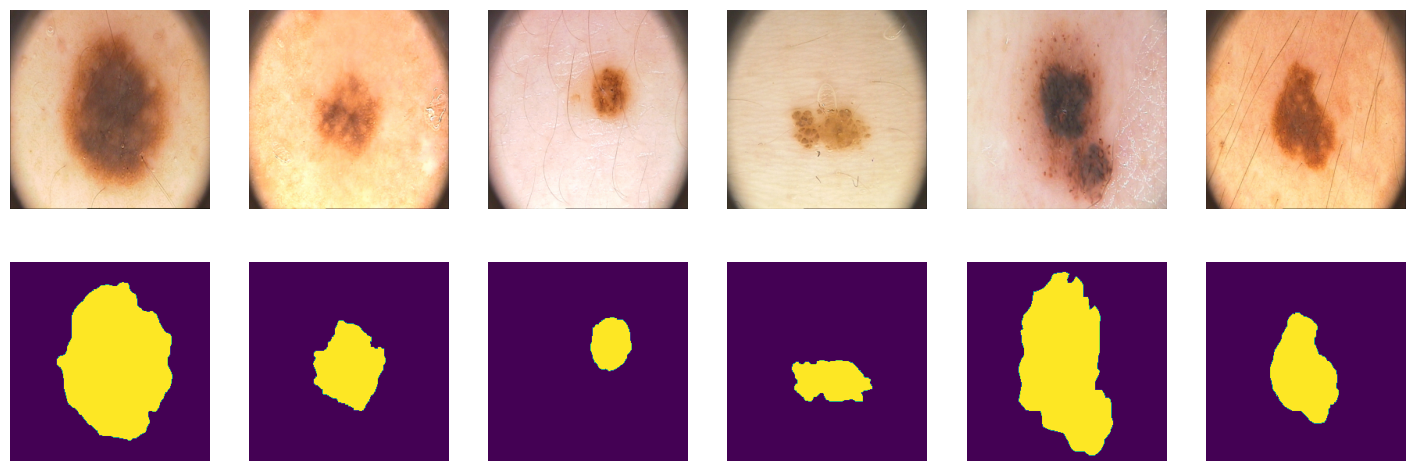

In [118]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show()

In [119]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [120]:
print(len(tr), len(val), len(ts))

100 50 50


In [121]:
import torch
import torchvision.transforms as T
import numpy as np

In [122]:
np.mean(np.random.randn(2, 3, 4), axis=(1, 2))

array([ 0.07892633, -0.28738573])

In [123]:
np.arange(10)**2
X[0].shape

(256, 256, 3)

In [124]:
mean = np.zeros(3)
std = np.zeros(3)
for i in tr:
    mean += np.sum(X[i], axis=(0, 1))
    std += np.sum(X[i]**2, axis=(0, 1))
mean /= len(tr) * np.prod(X[0].shape[:2])
std /= len(tr) * np.prod(X[0].shape[:2])
std - mean**2
print(f'mean: {mean}')
print(f'std: {std}')

mean: [0.7577369  0.57838651 0.48715078]
std: [0.61331394 0.37378815 0.2792579 ]


In [125]:
trans = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(15),
    T.RandomHorizontalFlip(),
    T.RandomResizedCrop(256, scale=(0.4, 0.9)),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),

    T.ToTensor(),
    # T.Normalize(torch.tensor(mean), torch.tensor(std))
])
def collate_fn(batch):

    # for x_batch, y_batch in batch:
    #     trans(x_batch.transpose(1, 2, 0))
    #     break
    # assert False
    x_batch, y_batch = zip(*batch)
    x_batch = torch.stack([ trans(t.transpose(1, 2, 0)) for t in x_batch ])
    y_batch = torch.stack([ torch.tensor(t) for t in y_batch])
    return x_batch, y_batch


In [126]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
# train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
#                      batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [127]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.act(x)
        return x



In [128]:
class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3):
        super().__init__()

        self.pool = nn.MaxPool2d(2, 2)

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)
        # self.sigma = nn.Sigmoid()


    def forward(self, x):
        out1 = self.enc1(x)
        out = self.pool(out1)
        out2 = self.enc2(out)
        out = self.pool(out2)
        out3 = self.enc3(out)
        out = self.pool(out3)
        out4 = self.enc4(out)
        out = self.pool(out4)

        out = self.bottleneck(out)

        out = self.up4(out)
        # print(out.shape, out4.shape)
        out = torch.cat([out, out4], axis=1)
        out = self.dec4(out)
        out = self.up3(out)
        # print(out.shape, out3.shape)
        out = torch.cat([out, out3], axis=1)
        out = self.dec3(out)
        out = self.up2(out)
        # print(out.shape, out2.shape)
        out = torch.cat([out, out2], axis=1)
        out = self.dec2(out)
        out = self.up1(out)
        # print(out.shape, out1.shape)
        out = torch.cat([out, out1], axis=1)
        out = self.dec1(out)
        print()

        out = self.out(out)
        # out = self.sigma(out)
        return out

## Обучите UNet

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [129]:
from tqdm.notebook import tqdm
import time

In [130]:
pred_unique = []
out_unique = []
y_unique = []
check = []
def train_epoch(model, train_loader, opt, criteion):
    global pred_unique
    global out_unique
    global y_unique
    train_loss = 0
    train_acc = 0
    num = 0


    model.train()
    for x_batch, y_batch in tqdm(train_loader):
        # return y_batch, y_batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        out = model(x_batch)
        pred = torch.where(out > 0.5, 1, 0)
        # print(pred.shape)
        # print(y_batch.shape)
        # print(pred == y_batch)
        # check.append(torch.isnan(pred.cpu()).any().item())
        # print(out.shape, y_batch.shape)
        # pred_unique += torch.unique(pred).cpu().numpy()
        out_unique += [out.min().item(), out.max().item()]
        # y_unique += torch.unique(y_batch).cpu().numpy()
        loss = criteion(out, y_batch)

        opt.zero_grad()
        loss.backward()
        for name, param in model.named_parameters():
            if param.grad is not None:
                # print("I am calc GRAD")
                grads[name].append(torch.norm(param.grad))
            else:
                grads[name].append(None)
        opt.step()

        train_acc += torch.sum(pred == y_batch).item()
        train_loss += loss.item()
        num += len(x_batch)

    train_loss /= num
    num *= np.prod(x_batch.shape[2:])
    train_acc /= num
    return train_loss, train_acc

def val_epoch(model, val_loader, criteion):
    val_loss = 0
    val_acc = 0
    num = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            out = model(x_batch)
            pred = torch.where(out > 0.5, 1, 0)
            # print(pred.shape)
            # print(y_batch.shape)
            # print(pred == y_batch)
            check.append(torch.isnan(pred.cpu()).any().item())
            loss = criteion(out, y_batch)

            val_acc += torch.sum(pred == y_batch).item()
            val_loss += loss.item()
            num += len(x_batch)

    val_loss /= num
    num *= np.prod(x_batch.shape[2:])
    val_acc /= num
    return val_loss, val_acc

In [131]:
def train(model, train_loader, val_loader, opt, criterion, epochs=30, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    lrs = [opt.param_groups[0]['lr']]

    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        for epoch in range(epochs):
            print(f"Epoch: {epoch}/{epochs}")
            train_loss, train_acc = train_epoch(model, train_loader, opt, criterion)
            val_loss, val_acc = val_epoch(model, val_loader, criterion)

            if scheduler is not None:
                try:
                    scheduler.step()
                except:
                    scheduler.step(val_acc)

            lrs.append(opt.param_groups[0]['lr'])

            # Update history
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # If you have a general dictionary, update it too
            try:
                general["train_loss"].append(train_loss)
                general["train_acc"].append(train_acc)
                general["val_loss"].append(val_loss)
                general["val_acc"].append(val_acc)
            except:
                # If general dict doesn't exist, just continue
                pass

            clear_output(wait=True)  # Clear previous output
            pbar_outer.update(1)

            # Print metrics
            print(f'Learning rates: {lrs}')
            print(f'Train loss: {train_loss}')
            print(f'Validation loss: {val_loss}')
            print(f'Train accuracy: {train_acc}')
            print(f'Validation accuracy: {val_acc}')

            # Create a new figure for each epoch
            plt.figure(figsize=(18, 6))

            # Loss plot
            plt.subplot(1, 3, 1)
            plt.plot(history['train_loss'], label='Train Loss', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Loss', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Loss', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=10)

            # Accuracy plot
            plt.subplot(1, 3, 2)
            plt.plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='royalblue', marker='o')
            plt.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='crimson', marker='o')
            plt.title('Training and Validation Accuracy', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Accuracy', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=10)

            # Learning rate plot
            plt.subplot(1, 3, 3)
            plt.plot(lrs, label='Learning Rate', linewidth=2, color='royalblue', marker='o')
            plt.title('Learning Rate through epochs', fontsize=14)
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Learning Rate', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend(fontsize=10)

            plt.tight_layout()
            plt.show()

    return history

In [132]:
general = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

Обучите модель **UNet**. В качестве оптимайзера можно взять Adam.

In [133]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [134]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"


In [ ]:
for name, param in unet.named_parameters():
    print(torch.isnan(param))

In [47]:
torch.cuda.empty_cache()

In [136]:
one_cnt = 0
zero_cnt = 0
for i in range(len(Y)):
    one_cnt += (Y[i] == 1).sum()
    zero_cnt += (Y[i] == 0).sum()
assert one_cnt + zero_cnt == 200 * 256**2
print(zero_cnt/one_cnt)

2.099301455966094


In [145]:

unet = UNet().to(device)
opt = torch.optim.AdamW(unet.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 'max', factor=0.6, patience=5)
scheduler = None
pos_weight = torch.tensor([zero_cnt/one_cnt]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='sum')
# criterion = bce_loss

In [146]:
val_dataloader = valid_dataloader

In [147]:
grads = {name: [] for name, _ in unet.named_parameters()}
grads

{'enc1.conv1.weight': [],
 'enc1.conv1.bias': [],
 'enc1.conv2.weight': [],
 'enc1.conv2.bias': [],
 'enc2.conv1.weight': [],
 'enc2.conv1.bias': [],
 'enc2.conv2.weight': [],
 'enc2.conv2.bias': [],
 'enc3.conv1.weight': [],
 'enc3.conv1.bias': [],
 'enc3.conv2.weight': [],
 'enc3.conv2.bias': [],
 'enc4.conv1.weight': [],
 'enc4.conv1.bias': [],
 'enc4.conv2.weight': [],
 'enc4.conv2.bias': [],
 'bottleneck.conv1.weight': [],
 'bottleneck.conv1.bias': [],
 'bottleneck.conv2.weight': [],
 'bottleneck.conv2.bias': [],
 'up4.weight': [],
 'up4.bias': [],
 'dec4.conv1.weight': [],
 'dec4.conv1.bias': [],
 'dec4.conv2.weight': [],
 'dec4.conv2.bias': [],
 'up3.weight': [],
 'up3.bias': [],
 'dec3.conv1.weight': [],
 'dec3.conv1.bias': [],
 'dec3.conv2.weight': [],
 'dec3.conv2.bias': [],
 'up2.weight': [],
 'up2.bias': [],
 'dec2.conv1.weight': [],
 'dec2.conv1.bias': [],
 'dec2.conv2.weight': [],
 'dec2.conv2.bias': [],
 'up1.weight': [],
 'up1.bias': [],
 'dec1.conv1.weight': [],
 'dec1

Learning rates: [0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003]
Train loss: 34553.415
Validation loss: 36102.655
Train accuracy: 0.8411492919921875
Validation accuracy: 0.842947998046875


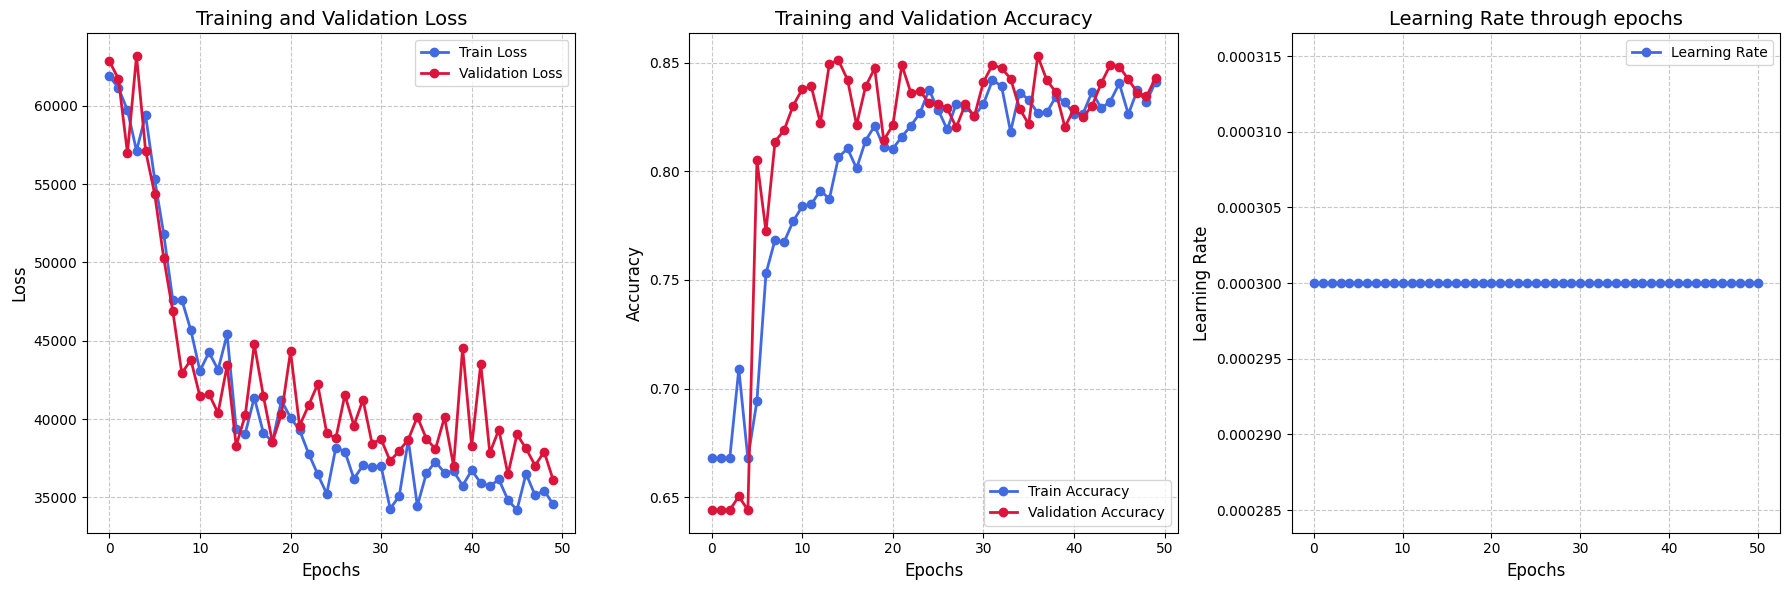

In [148]:
out_unique = []
history = train(unet, train_dataloader, val_dataloader, opt, criterion, epochs=50, scheduler=scheduler)

In [109]:
out_unique

[-0.10436458885669708,
 -0.08699383586645126,
 -0.10848632454872131,
 -0.08683698624372482,
 -0.11214671283960342,
 -0.08622271567583084,
 -0.11673082411289215,
 -0.08618822693824768,
 -0.12087079882621765,
 -0.08615671843290329,
 -0.12405115365982056,
 -0.0854465588927269,
 -0.12872406840324402,
 -0.08526349812746048,
 -0.13325336575508118,
 -0.08502286672592163,
 -0.13974937796592712,
 -0.08521776646375656,
 -0.14569514989852905,
 -0.08487968891859055,
 -0.1525758057832718,
 -0.0843634307384491,
 -0.16058588027954102,
 -0.08386342227458954,
 -0.1690542846918106,
 -0.08364451676607132,
 -0.17420616745948792,
 -0.08301585167646408,
 -0.18774919211864471,
 -0.08163179457187653,
 -0.1982346773147583,
 -0.08084699511528015,
 -0.2102918028831482,
 -0.07882780581712723,
 -0.22318710386753082,
 -0.07801241427659988,
 -0.23641371726989746,
 -0.07450054585933685,
 -0.2525162696838379,
 -0.07081491500139236,
 -0.27176469564437866,
 -0.06783105432987213,
 -0.294099897146225,
 -0.0627531930804252

In [95]:
for name, val in grads.items():
    print(name, type(val))

enc1.conv1.weight <class 'list'>
enc1.conv1.bias <class 'list'>
enc1.conv2.weight <class 'list'>
enc1.conv2.bias <class 'list'>
enc2.conv1.weight <class 'list'>
enc2.conv1.bias <class 'list'>
enc2.conv2.weight <class 'list'>
enc2.conv2.bias <class 'list'>
enc3.conv1.weight <class 'list'>
enc3.conv1.bias <class 'list'>
enc3.conv2.weight <class 'list'>
enc3.conv2.bias <class 'list'>
enc4.conv1.weight <class 'list'>
enc4.conv1.bias <class 'list'>
enc4.conv2.weight <class 'list'>
enc4.conv2.bias <class 'list'>
bottleneck.conv1.weight <class 'list'>
bottleneck.conv1.bias <class 'list'>
bottleneck.conv2.weight <class 'list'>
bottleneck.conv2.bias <class 'list'>
up4.weight <class 'list'>
up4.bias <class 'list'>
dec4.conv1.weight <class 'list'>
dec4.conv1.bias <class 'list'>
dec4.conv2.weight <class 'list'>
dec4.conv2.bias <class 'list'>
up3.weight <class 'list'>
up3.bias <class 'list'>
dec3.conv1.weight <class 'list'>
dec3.conv1.bias <class 'list'>
dec3.conv2.weight <class 'list'>
dec3.conv2.

In [ ]:
grads = {name: [el.cpu() for el in val] for name, val in grads.items()}

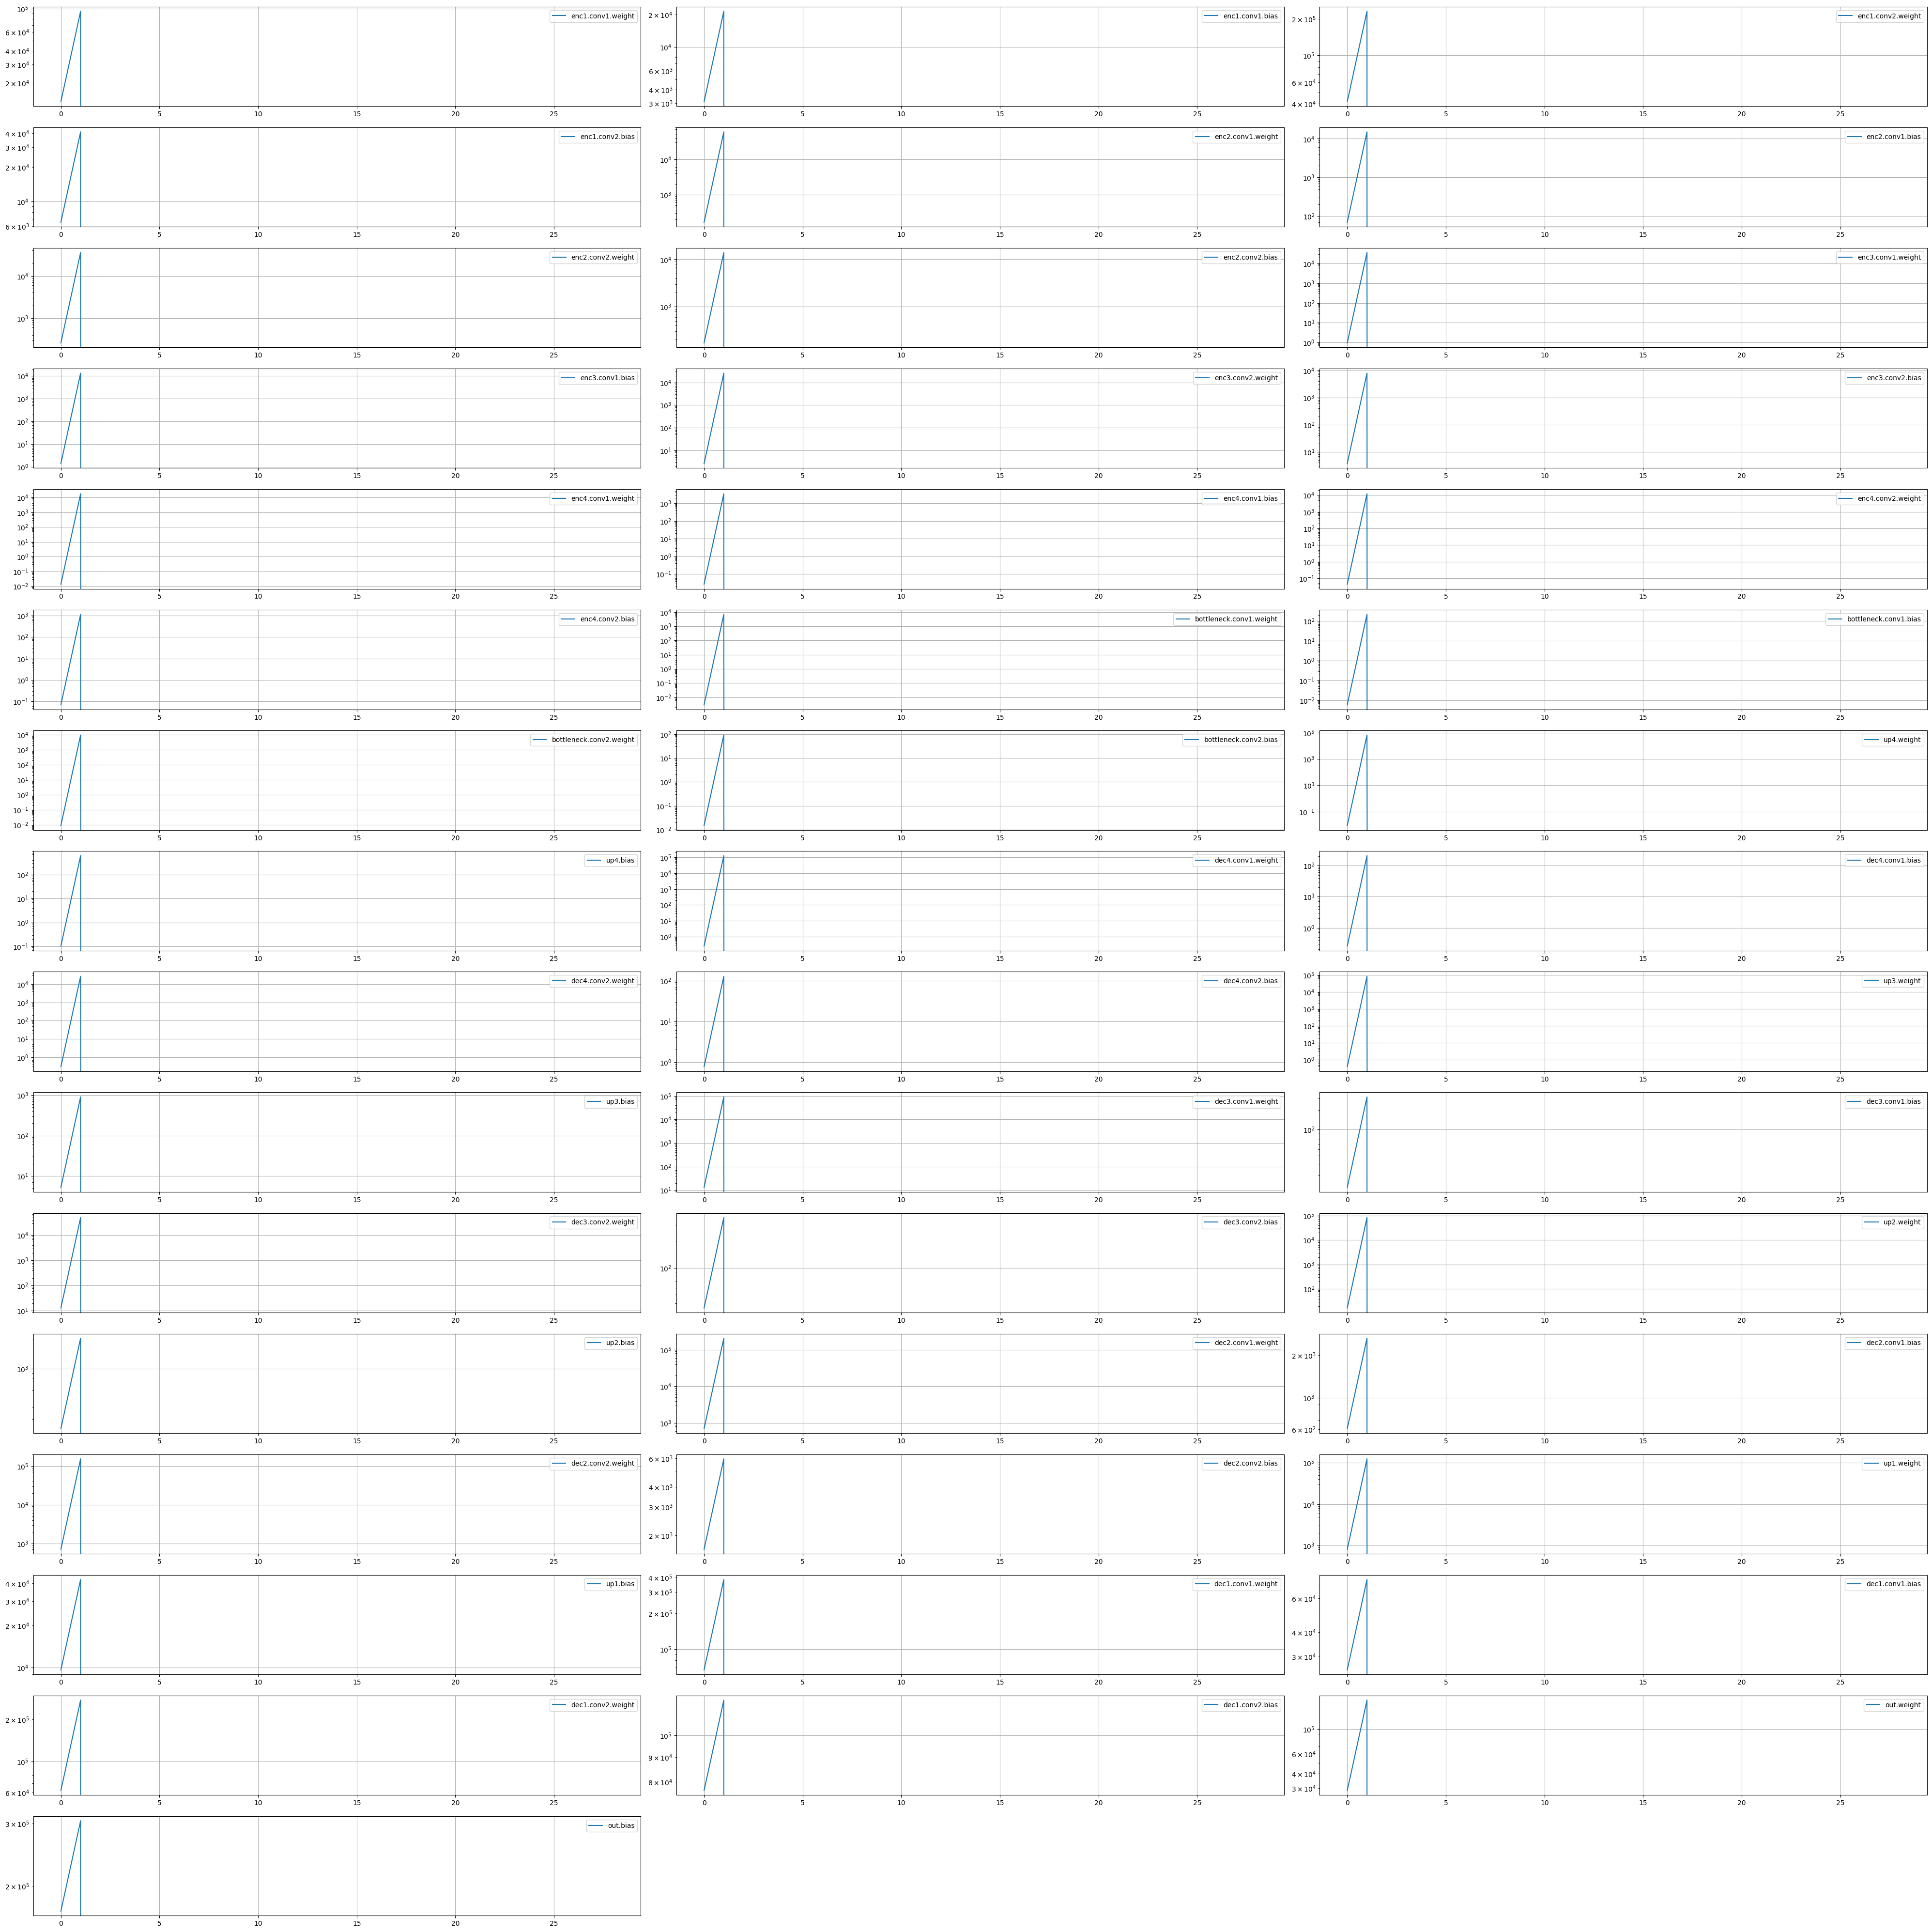

In [111]:
plt.figure(figsize=(40, 40))
for i, (name, grad) in enumerate(grads.items()):
    plt.subplot(len(grads)//3 + 1, 3, i+1)
    plt.plot(grad, label=name)
    # plt.title(f'{name}\nMax: {max(grads):.2e}')
    plt.yscale('log')  # Better for visualizing wide ranges
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

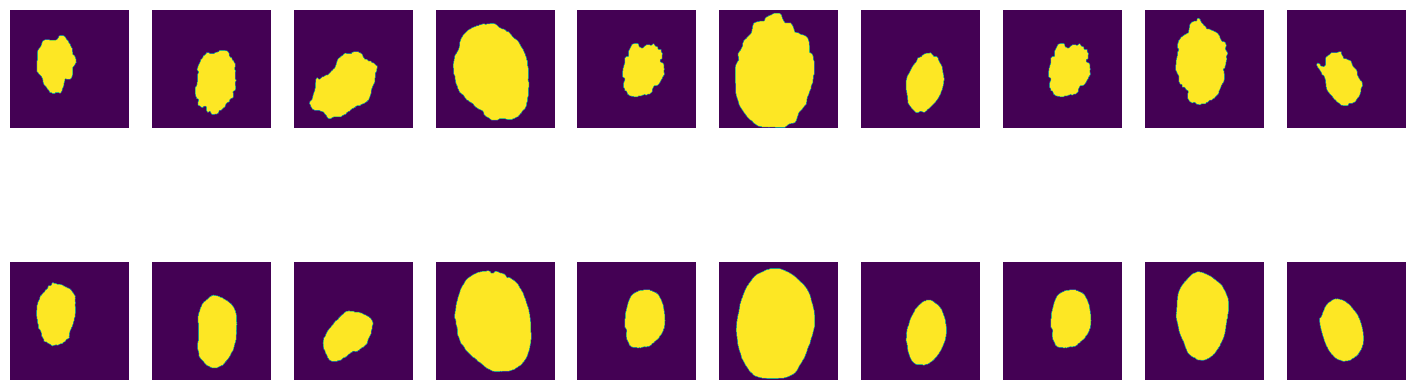

In [111]:
ind = np.random.choice(len(X), 10, replace=True)
plt.figure(figsize=(18, 6))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.axis("off")
    plt.imshow(Y[ind[i]])

    plt.subplot(2, 10, i+11)
    plt.axis("off")
    ans = T.ToTensor()(X[ind[i]]).unsqueeze(0).to(device)
    # print(ans.shape)
    ans = unet(ans).squeeze()
    # print(ans.shape)
    ans = torch.where(ans > 0.5, 1, 0)
    plt.imshow(ans.cpu().detach().numpy())
plt.show()

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.

